[[b'1', b'3', b'1', b'1', b'1', b'1', b'1', 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0], [b'1', b'3', b'1', b'1', b'2', b'1', b'1', 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0], [b'1', b'3', b'1', b'1', b'2', b'1', b'1', 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0], [b'1', b'2', b'1', b'1', b'1', b'1', b'1', 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0], [b'1', b'1', b'1', b'1', b'2', b'1', b'1', 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0], [b'1', b'2', b'1', b'1', b'2', b'1', b'1', 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0], [b'1', b'3', b'1', b'1', b'2', b'1', b'1', 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0], [b'1', b'3', b'1', b'1', b'2', b'1', b'1', 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0], [b'1', 

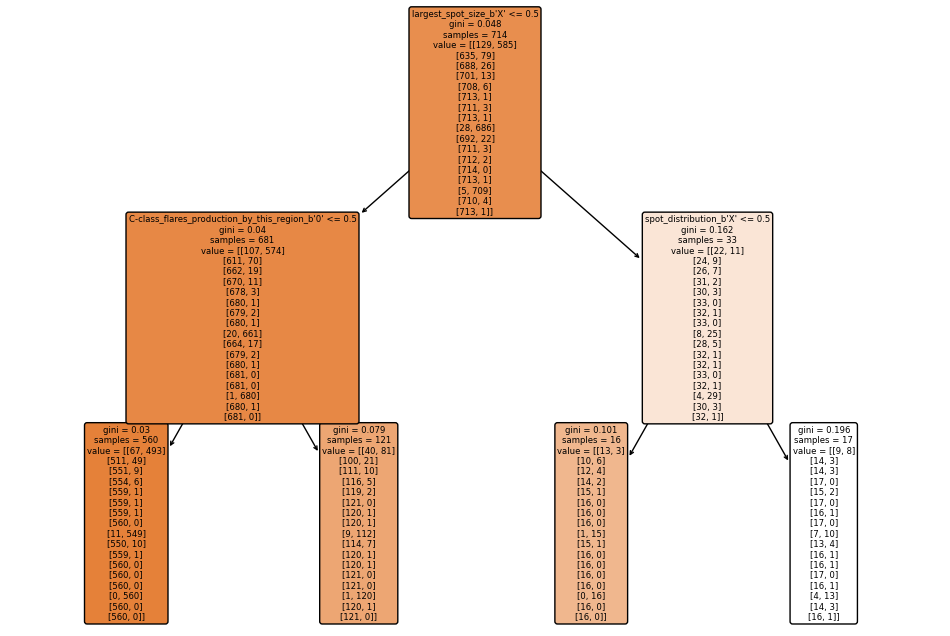

In [2]:
from scipy.io import arff
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder 
import numpy as np

# Load ARFF file
arff_file_path = 'solar_flare_classification_data.arff'  
data, meta = arff.loadarff(arff_file_path)

# Convert data to a Pandas DataFrame
df = pd.DataFrame(data)

#This solar flair data has 1066 samples a d 13 attributes (including the 3 classes to predict). All samples are from one active reigon of the sun.
#The attributes are:
# %  Attribute Information:
# %    1. Code for class (modified Zurich class)  (A,B,C,D,E,F,H)
# %    2. Code for largest spot size              (X,R,S,A,H,K)
# %    3. Code for spot distribution              (X,O,I,C)
# %    4. Activity                                (1 = reduced, 2 = unchanged)
# %    5. Evolution                               (1 = decay, 2 = no growth, 
# %                                                3 = growth)
# %    6. Previous 24 hour flare activity code    (1 = nothing as big as an M1,
# %                                                2 = one M1,
# %                                                3 = more activity than one M1)
# %    7. Historically-complex                    (1 = Yes, 2 = No)
# %    8. Did region become historically complex  (1 = yes, 2 = no) 
# %       on this pass across the sun's disk
# %    9. Area                                    (1 = small, 2 = large)
# %   10. Area of the largest spot                (1 = <=5, 2 = >5)
# % 
# %  From all these predictors three classes of flares are predicted, which are 
# %  represented in the last three columns.
# % 
# %   11. C-class flares production by this region    Number  
# %       in the following 24 hours (common flares)
# %   12. M-class flares production by this region    Number
# %       in the following 24 hours (moderate flares)
# %   13. X-class flares production by this region    Number
# %       in the following 24 hours (severe flares)

#The three classes to predict (C-class, M-class, X-class) output numbers that indicate how many of those classes of flares were detected
#in the active riegon that is being viewed. So, it is possible for a signle sample of data to have numbers in all three classes. 


Features = []
Classes = []

for i in range(1066):
    row_as_list = df.iloc[i].tolist()
    
    # Append elements 9, 8, and 7 as one list to Classes
    Classes.append([row_as_list[23], row_as_list[24], row_as_list[25], row_as_list[26], row_as_list[27],
                   row_as_list[28], row_as_list[29], row_as_list[30], row_as_list[31], row_as_list[32],
                   row_as_list[33],row_as_list[34],row_as_list[35],row_as_list[36],row_as_list[37],
                   row_as_list[38],row_as_list[39]])
    
    # Append the remaining elements of row_as_list to Features
    Features.append(row_as_list)

X, y = Features, Classes




In [36]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.tree import DecisionTreeClassifier
import numpy as np

# Create an instance of the DecisionTreeClassifier
clf = DecisionTreeClassifier(max_depth=2)

mean_error_list = []
std_dev_error_list = []

for i in range(10):
    # Define the number of folds for cross-validation
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)

    # Perform cross-validation
    scores = cross_val_score(clf, X, y, cv=kfold, scoring='accuracy')

    # Calculate mean and standard deviation of the errors
    mean_error = np.mean(scores)
    std_dev_error = np.std(scores)
    mean_error_list.append(mean_error)
    std_dev_error_list.append(std_dev_error)

# Calculate the average mean error and standard deviation
Average_mean_error = np.mean(mean_error_list)
Average_std_dev_error = np.mean(std_dev_error_list)

print("Mean Error Average (10):", Average_mean_error)
print("Standard Deviation of Error Average (10):", Average_std_dev_error)


Mean Error Average (10): 0.8029536236995239
Standard Deviation of Error Average (10): 0.030307888939989907
